In [27]:
import tqdm
import pandas
import joblib
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA

from utils import estimate_quality

In [28]:
data = pandas.read_csv("churn.csv")
data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

X = data.drop(columns = ["Churn"])
# y = data["Churn"].to_numpy()
y = (data["Churn"] == "Yes").to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))
ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

### V0 (do not touch)

In [29]:
classifier = LazyFCA(
    pos_params=LazyFCA.Params(
        supporters_covered=5,
        supporter_opposer_ratio=1 / 2.75,
    ),
    neg_params=LazyFCA.Params(
        supporters_covered=10,
        supporter_opposer_ratio=4,
    ),
    pos_weight=1.0
)
classifier.fit(X_train, y_train)

In [30]:
y_pred = classifier.predict(X_test)
estimate_quality(y_pred, y_test)

100%|██████████| 704/704 [00:51<00:00, 13.63it/s]


{'Accuracy': 0.7571022727272727,
 'Precision': 0.5289855072463768,
 'Recall': 0.7807486631016043,
 'AUC-ROC': 0.8241448504845933,
 'F1-score': 0.6306695464362851,
 'True Positive': 146,
 'True Negative': 387,
 'False Positive': 130,
 'False Negative': 41,
 'True Negative Rate (Specificity)': 0.7485493230174082,
 'Negative Predictive Value': 0.9042056074766355,
 'False Positive Rate': 0.2514506769825919,
 'False Discovery Rate': 0.47101449275362317}

In [31]:
score = classifier.explain_sample(X_test.iloc[502]).display()
score

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0...,POSITIVE,1682,4646,5,6,0.833333,0.002973,0.001291,0.454545,1.710085,0.000328,0.001681,0.001681,0.017829,0.018586,0.002572,0.846154,1672.022612,-70.175257
1,0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0...,POSITIVE,1682,4646,7,14,0.500000,0.004162,0.003013,0.333333,1.254063,0.000224,0.001148,0.001148,0.008821,0.025823,0.006000,0.517241,1668.071319,-104.703372
2,0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,341,874,0.390160,0.202735,0.188119,0.280658,1.055890,0.002852,0.014616,0.014616,0.016393,0.492733,0.299748,0.390509,1233.548422,-2660.553217
3,0; 0; 0; 0; 1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,6,12,0.500000,0.003567,0.002583,0.333333,1.254063,0.000192,0.000984,0.000984,0.008165,0.022684,0.005146,0.520000,1670.052397,-91.600731
4,0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0...,POSITIVE,1682,4646,5,13,0.384615,0.002973,0.002798,0.277778,1.045052,0.000034,0.000175,0.000175,0.001448,0.020090,0.005580,0.407407,1672.051239,-84.146600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 0; 1; 0...,NEGATIVE,4646,1682,244,26,9.384615,0.052518,0.015458,0.903704,1.230873,0.007232,0.037061,0.037061,0.081006,0.170088,0.027918,9.226415,4171.216367,-1489.533730
3551,0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0...,NEGATIVE,4646,1682,25,0,inf,0.005381,0.000000,1.000000,1.362032,0.001050,0.005381,0.005381,0.037894,0.028115,-0.000029,51.000000,4596.134524,-261.244304
3552,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0...,NEGATIVE,4646,1682,32,0,inf,0.006888,0.000000,1.000000,1.362032,0.001344,0.006888,0.006888,0.042896,0.034287,-0.000047,65.000000,4582.220405,-318.593665
3553,0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 1; 0; 0...,NEGATIVE,4646,1682,74,1,74.000000,0.015928,0.000595,0.986667,1.343871,0.002992,0.015333,0.015333,0.062591,0.066530,0.000935,49.666667,4499.179243,-614.674535


In [32]:
all_explanations = classifier.explain(X_test)
len(all_explanations)

100%|██████████| 704/704 [01:11<00:00,  9.84it/s]


704

In [33]:
scores = pandas.concat(map(lambda explanation: explanation.display(), all_explanations), axis = 0).drop_duplicates()
scores

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,139,132,1.053030,0.082640,0.028412,0.512915,1.929683,0.010583,0.054228,0.054228,0.118322,0.234047,0.049187,1.052830,1419.237243,-953.341291
1,0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,55,49,1.122449,0.032699,0.010547,0.528846,1.989619,0.004323,0.022152,0.022152,0.076970,0.122335,0.019913,1.121212,1574.315243,-473.726007
2,0; 0; 0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,171,103,1.660194,0.101665,0.022170,0.624088,2.347935,0.015514,0.079495,0.079495,0.172543,0.254335,0.033512,1.657005,1359.668131,-985.537213
3,0; 0; 0; 0; 1; 0; 1; 0; 1; 0; 1; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,41,41,1.000000,0.024376,0.008825,0.500000,1.881094,0.003035,0.015551,0.015551,0.060744,0.099321,0.016978,1.000000,1601.361222,-386.198790
4,0; 0; 0; 0; 1; 0; 1; 0; 1; 0; 1; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,73,76,0.960526,0.043401,0.016358,0.489933,1.843220,0.005277,0.027043,0.027043,0.078786,0.152384,0.030565,0.960784,1540.411472,-608.792737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670,0; 0; 0; 0; 1; 0; 0; 1; 1; 0; 0; 0; 1; 0; 0; 0...,NEGATIVE,4646,1682,15,0,inf,0.003229,0.000000,1.000000,1.362032,0.000630,0.003229,0.003229,0.029329,0.018518,-0.000010,31.000000,4616.048429,-172.071351
1671,0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 1...,NEGATIVE,4646,1682,18,4,4.500000,0.003874,0.002378,0.818182,1.114390,0.000292,0.001496,0.001496,0.011229,0.023891,0.004736,4.111111,4610.079250,-207.912526
1672,0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,20,0,inf,0.004305,0.000000,1.000000,1.362032,0.000840,0.004305,0.004305,0.033880,0.023453,-0.000019,41.000000,4606.086096,-217.921186
1673,0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0...,NEGATIVE,4646,1682,38,9,4.222222,0.008179,0.005351,0.808511,1.101217,0.000552,0.002828,0.002828,0.014552,0.044647,0.010606,4.052632,4570.358962,-383.221114


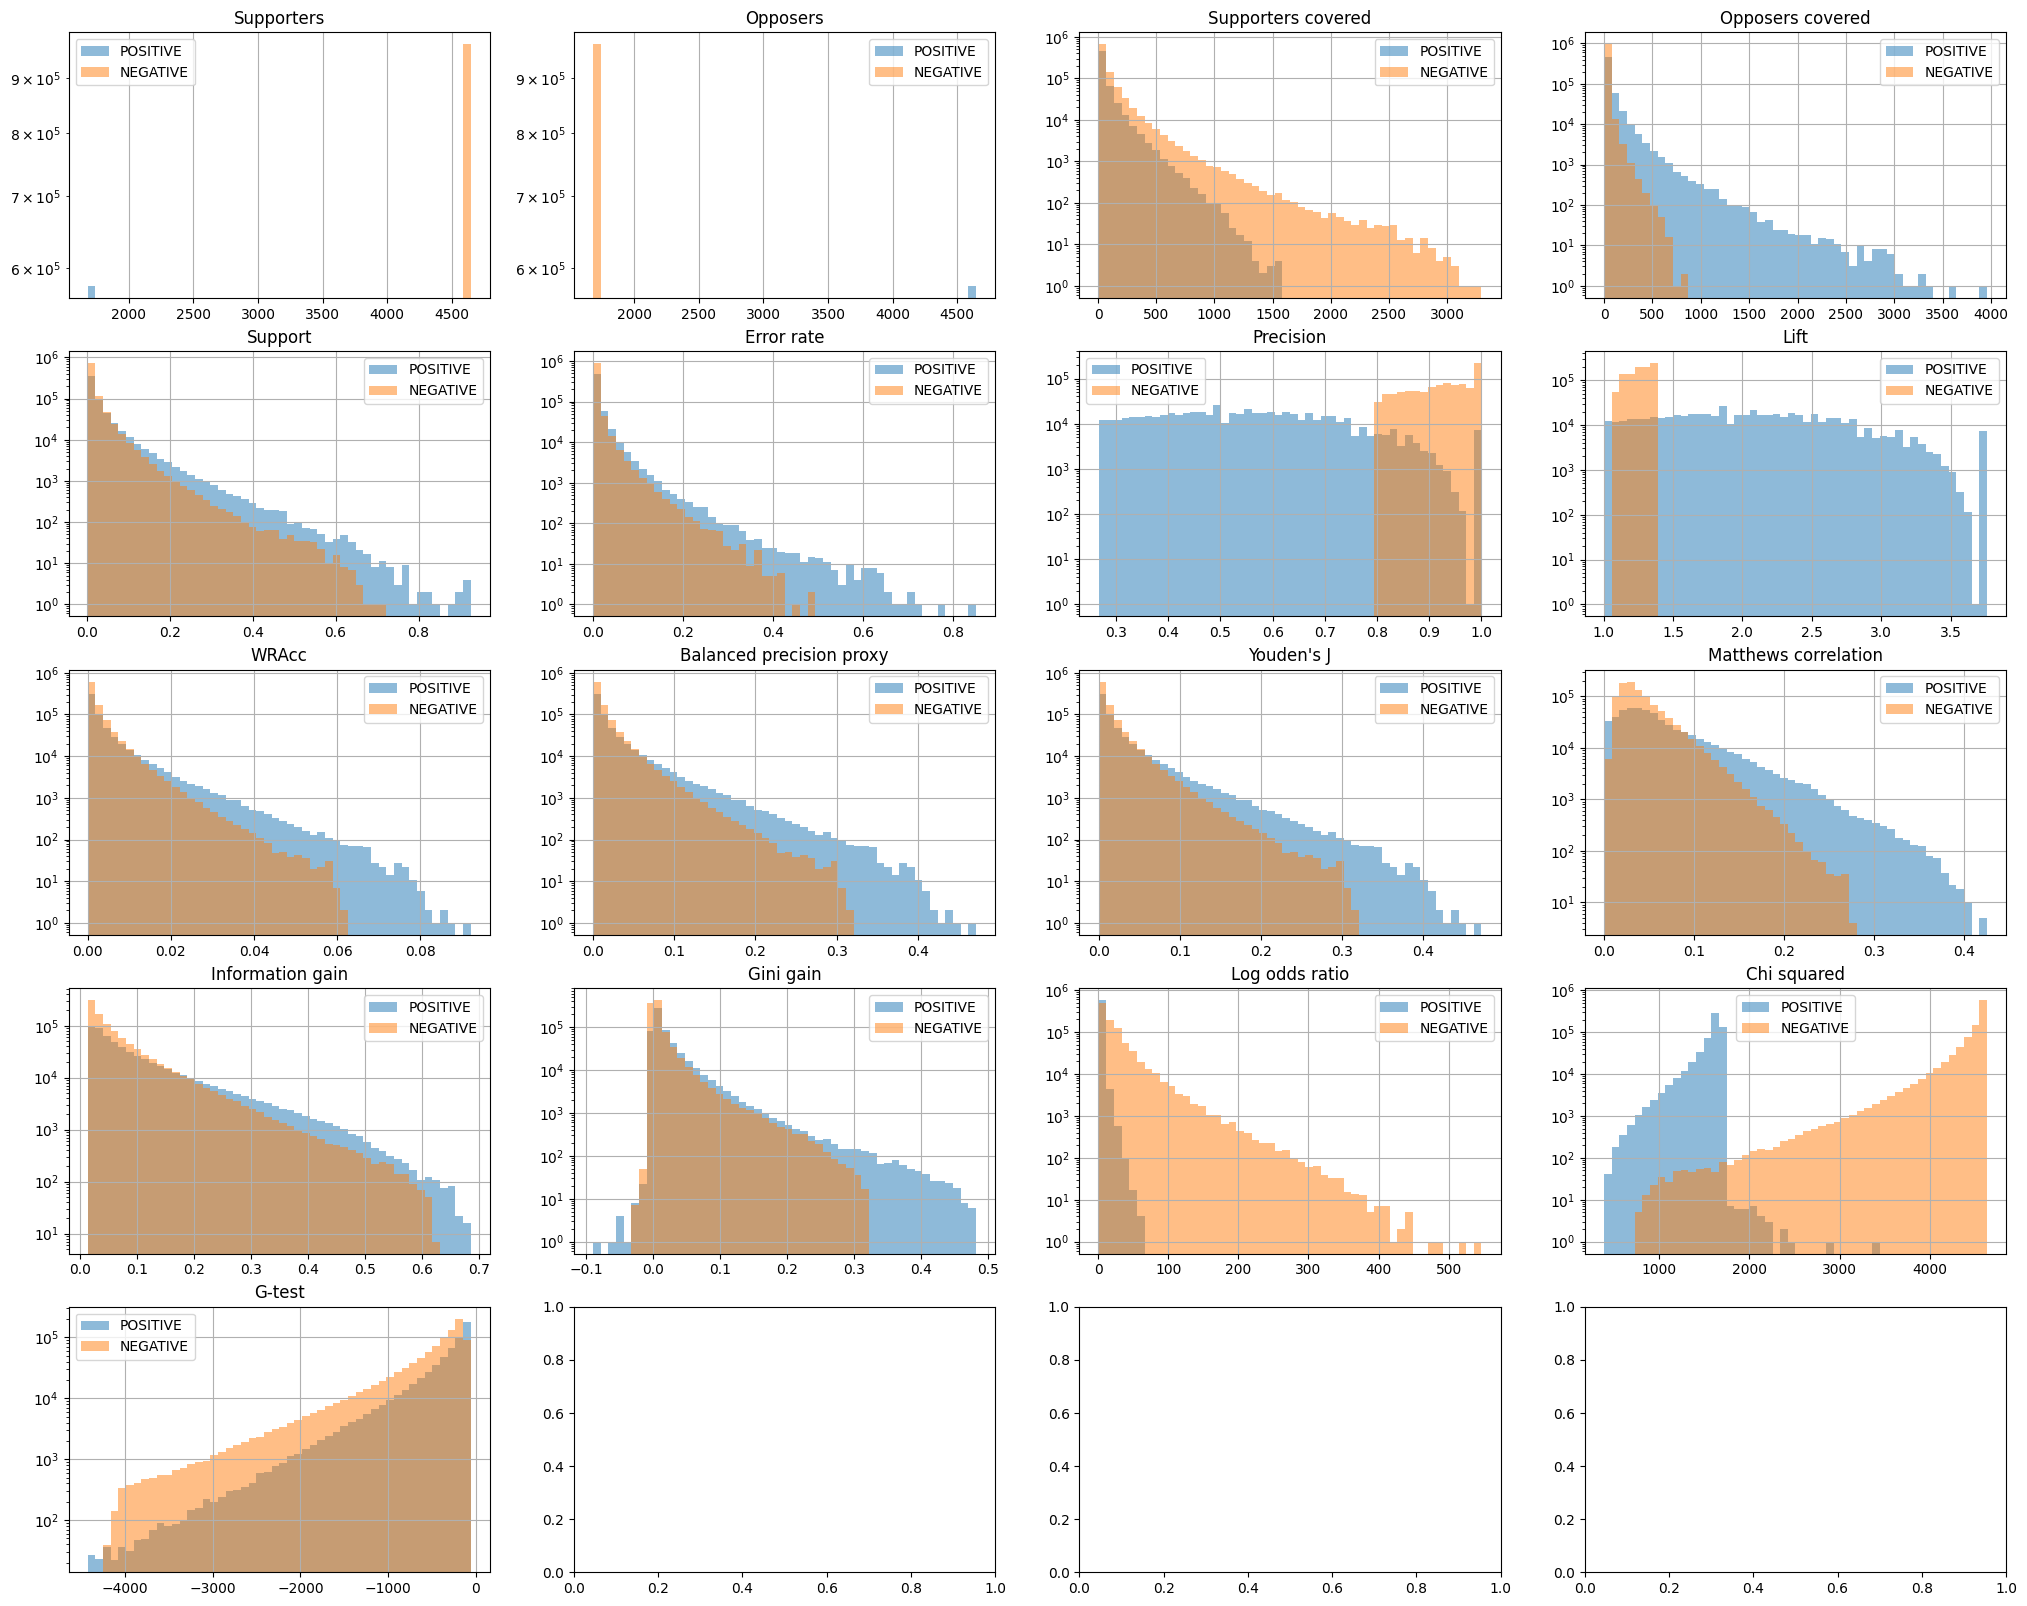

In [35]:
COLUMNS = [
    'Supporters', 'Opposers', 'Supporters covered', 'Opposers covered',
    'Support', 'Error rate', 'Precision', 'Lift', 'WRAcc',
    'Balanced precision proxy', 'Youden\'s J', 'Matthews correlation',
    "Information gain", "Gini gain", "Log odds ratio", "Chi squared", "G-test"
]
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    range = (scores[column].min(), scores[column].max())
    scores[scores["Type"] == "POSITIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'POSITIVE')
    scores[scores["Type"] == "NEGATIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'NEGATIVE')
    ax.legend()
    ax.set_yscale('log')

### V1

In [46]:
classifier = LazyFCA(
    pos_params=LazyFCA.Params(
        supporters_covered=100, #5,
        supporter_opposer_ratio=2, # 1 / 2.75,
        matthews_correlation=0.25,
        # information_gain=0.4,
    ),
    neg_params=LazyFCA.Params(
        supporters_covered=1500, #10,
        supporter_opposer_ratio=4,
        matthews_correlation=0.2,
        # information_gain=0.4,
    ),
    pos_weight=3.5, # 1.0
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
display(estimate_quality(y_pred, y_test))
classifier.explain_sample(X_test.iloc[502]).display()

100%|██████████| 704/704 [01:03<00:00, 11.07it/s]


{'Accuracy': 0.7386363636363636,
 'Precision': 0.5112781954887218,
 'Recall': 0.36363636363636365,
 'AUC-ROC': 0.6475139378768916,
 'F1-score': 0.425,
 'True Positive': 68,
 'True Negative': 452,
 'False Positive': 65,
 'False Negative': 119,
 'True Negative Rate (Specificity)': 0.874274661508704,
 'Negative Predictive Value': 0.7915936952714536,
 'False Positive Rate': 0.12572533849129594,
 'False Discovery Rate': 0.48872180451127817}

""


In [47]:
all_explanations = classifier.explain(X_test)
scores = pandas.concat(map(lambda explanation: explanation.display(), all_explanations), axis = 0).drop_duplicates()
scores

100%|██████████| 704/704 [01:03<00:00, 11.02it/s]


,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,361,177,2.039548,0.214625,0.038097,0.671004,2.524442,0.034450,0.176528,0.176528,0.279599,0.367641,0.028679,2.036620,1044.223006,-1458.227035
1,0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,297,126,2.357143,0.176576,0.027120,0.702128,2.641536,0.029166,0.149455,0.149455,0.264353,0.332932,0.022326,2.351779,1143.860058,-1278.551531
2,0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,341,163,2.092025,0.202735,0.035084,0.676587,2.545449,0.032717,0.167651,0.167651,0.273547,0.357997,0.027836,2.088685,1074.851263,-1408.587281
0,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,1835,225,8.155556,0.394963,0.133769,0.890777,1.213266,0.050972,0.261194,0.261194,0.246247,0.491300,0.093648,8.139690,1730.855954,-3827.753257
1,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,1819,224,8.120536,0.391520,0.133175,0.890357,1.212695,0.050416,0.258345,0.258345,0.244086,0.491021,0.095326,8.104677,1750.005282,-3828.173073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,0; 0; 1; 0; 0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,259,98,2.642857,0.153983,0.021093,0.725490,2.729430,0.025934,0.132890,0.132890,0.254441,0.308958,0.018031,2.634518,1205.948843,-1163.049939
23,0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,468,223,2.098655,0.278240,0.047998,0.677279,2.548052,0.044932,0.230242,0.230242,0.326117,0.402772,0.016275,2.096197,886.920025,-1632.518130
0,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,363,181,2.005525,0.215815,0.038958,0.667279,2.510431,0.034514,0.176856,0.176856,0.278714,0.369105,0.029823,2.002755,1041.392108,-1468.057101
1,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,320,159,2.012579,0.190250,0.034223,0.668058,2.513361,0.030449,0.156027,0.156027,0.260581,0.349334,0.031080,2.009404,1108.321360,-1374.522807


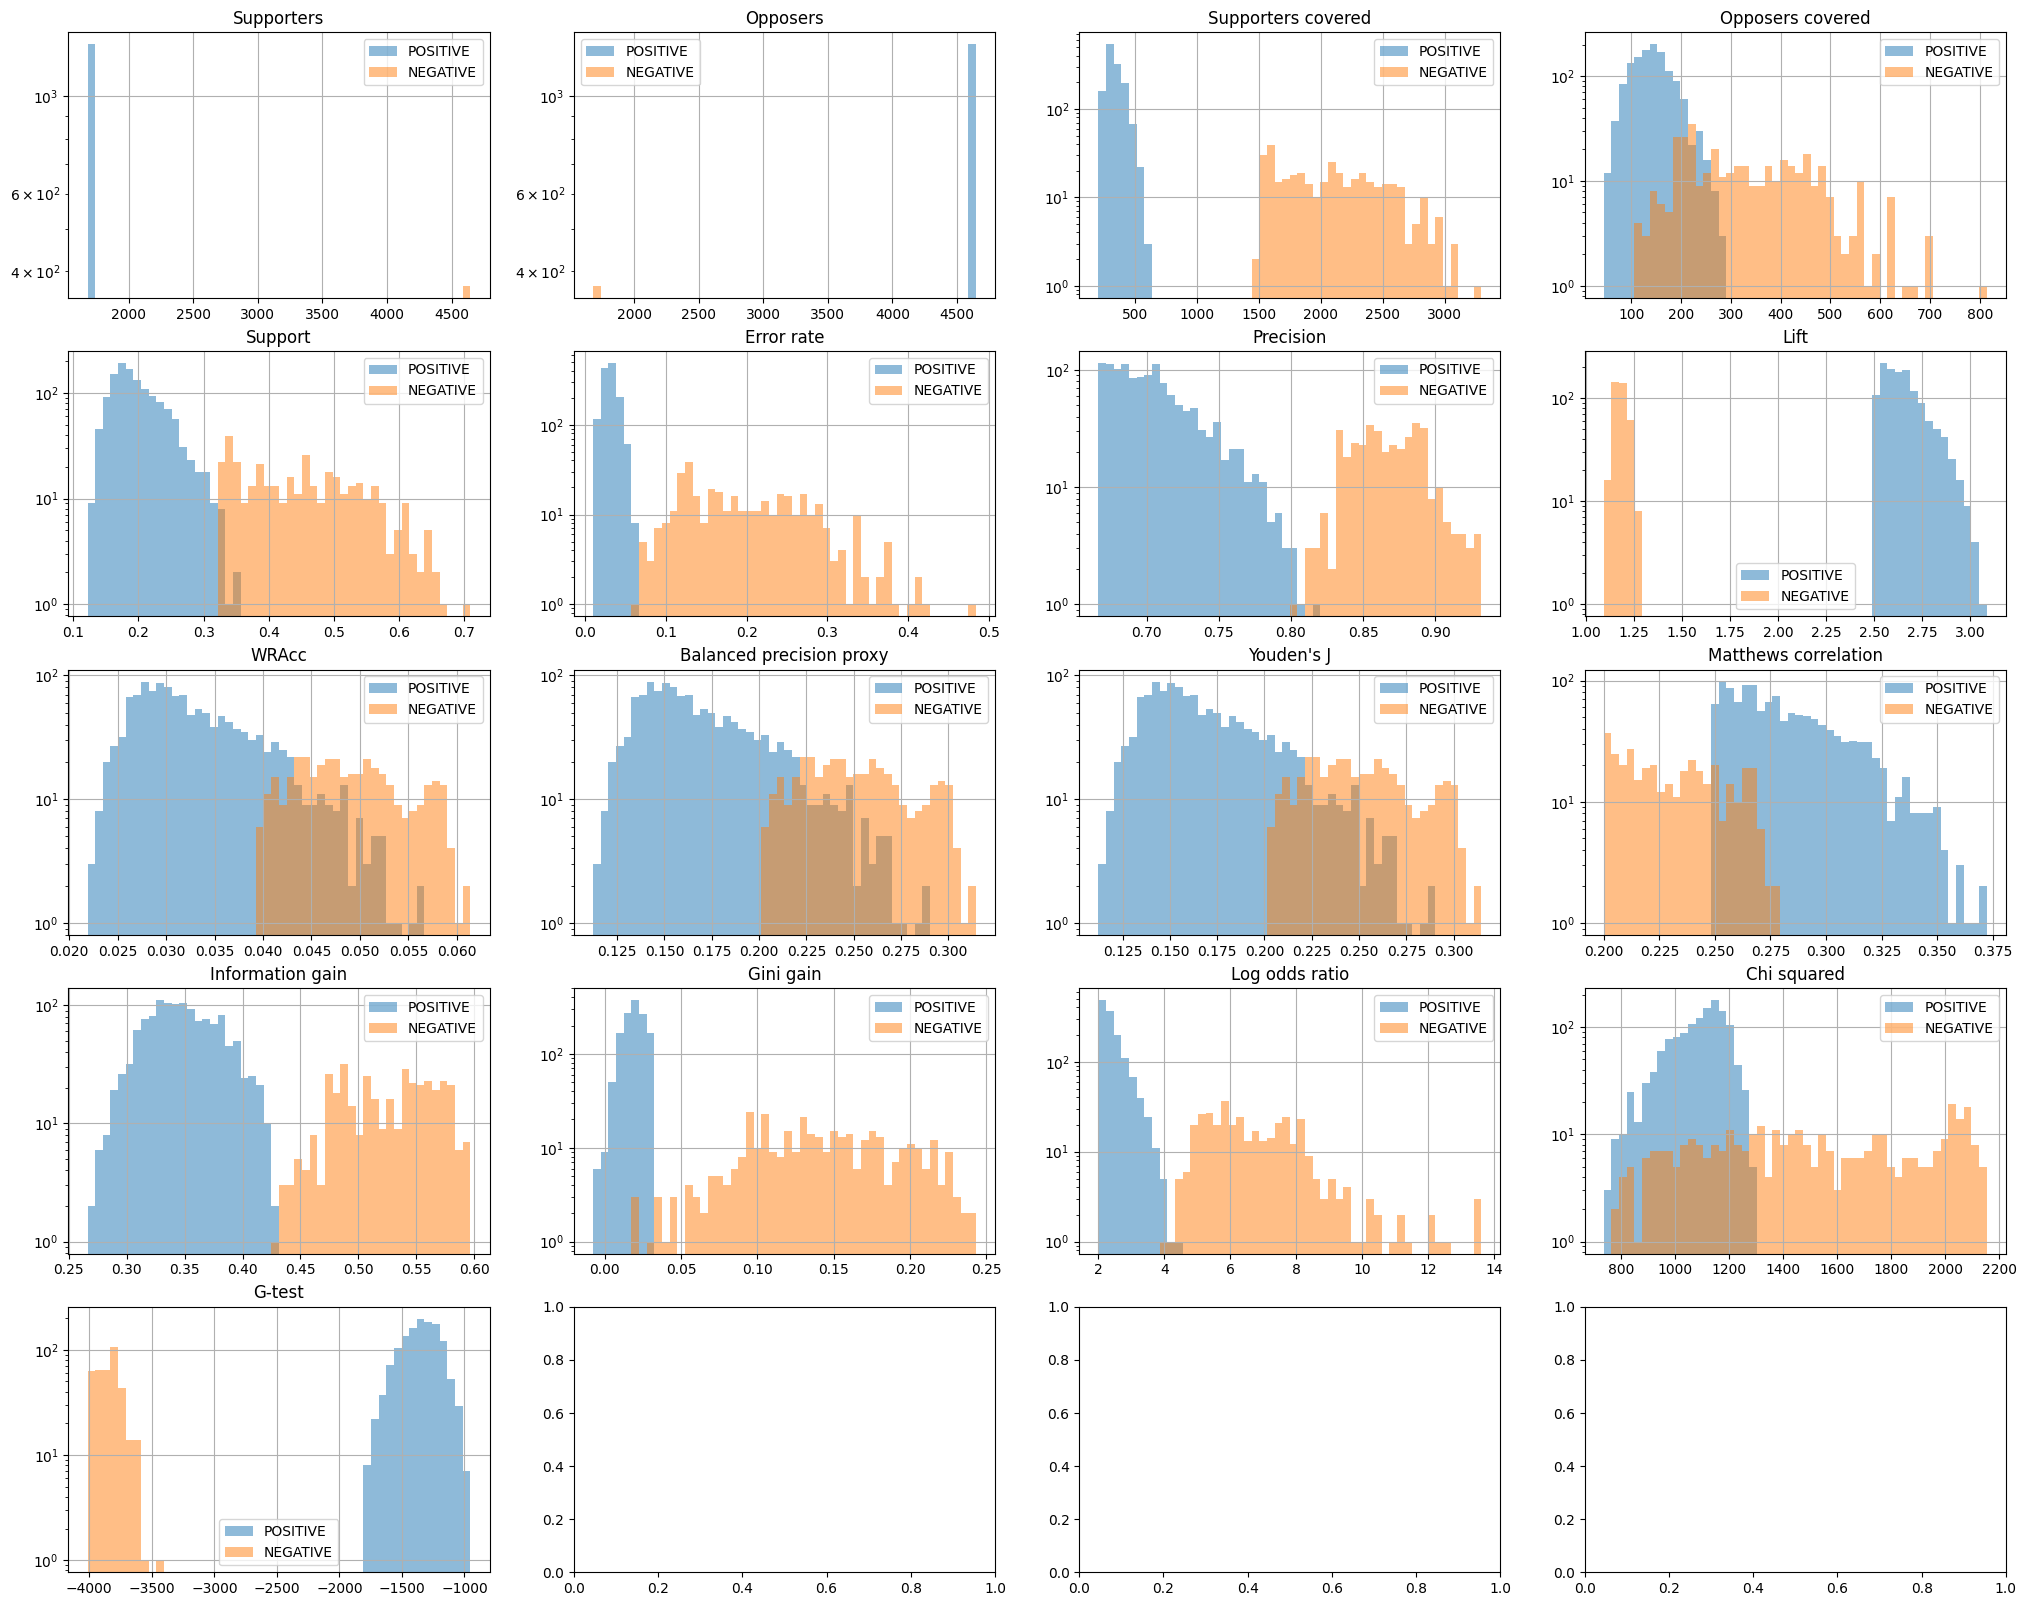

In [48]:
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    range = (scores[column].min(), scores[column].max())
    scores[scores["Type"] == "POSITIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'POSITIVE')
    scores[scores["Type"] == "NEGATIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'NEGATIVE')
    ax.legend()
    ax.set_yscale('log')

In [3]:
all_explanations = LazyFCA().fit(X_train, y_train).explain(X_test)
len(all_explanations)

 11%|█▏        | 80/704 [00:09<01:25,  7.30it/s]

KeyboardInterrupt: 

In [ ]:
import tqdm
import joblib
import itertools
from lazyfca.classifier import Classifier

supporter_opposer_ratio = [0.33, 0.66, 1.0, 2.5, 4.0]
support = [0.0, 0.05, 0.1, 0.2]
error_rate = [0.0, 0.05, 0.1, 0.2]
lift = [1.0, 2.0, 2.5]
wracc = [0.0, 0.015, 0.05]
balanced_precision_proxy = [0.0, 0.05, 0.25]
youdens_j = [0.0, 0.05, 0.25]
matthews_correlation = [0.0, 0.05, 0.25]
pos_weight = [0.5, 1.0, 1.5]

pos_param_values = itertools.product(
    supporter_opposer_ratio,
    support,
    error_rate,
    lift,
    wracc,
    balanced_precision_proxy,
    youdens_j,
    matthews_correlation,
)
neg_param_values = itertools.product(
    supporter_opposer_ratio,
    support,
    error_rate,
    lift,
    wracc,
    balanced_precision_proxy,
    youdens_j,
    matthews_correlation,
)
num_params = (
    len(supporter_opposer_ratio) *
    len(support) *
    len(error_rate) *
    len(lift) *
    len(wracc) *
    len(balanced_precision_proxy) *
    len(youdens_j) *
    len(matthews_correlation)
)

def make_metrics(params: tuple) -> Classifier.Metrics:
    return Classifier.Metrics(
        supporter_opposer_ratio=params[0],
        support=params[1],
        error_rate=params[2],
        lift=params[3],
        wracc=params[4],
        balanced_precision_proxy=params[5],
        youdens_j=params[6],
        matthews_correlation=params[7]
    )

def try_params(pos_params, neg_params, pos_weight):
    classifier = LazyFCA(
        pos_params=make_metrics(pos_params),
        neg_params=make_metrics(neg_params),
        pos_weight=pos_weight
    )
    classifier.fit(X_train, y_train)
    y_pred = classifier.classify_explanations(all_explanations, trust = False)
    return {
        "Positive": make_metrics(pos_params).to_dict(),
        "Negative": make_metrics(neg_params).to_dict(),
        **estimate_quality(y_pred, y_test)
    }

params = itertools.product(pos_param_values, neg_param_values, pos_weight)
total_params = num_params * num_params * len(pos_weight)
results = joblib.Parallel(n_jobs=1)(
    joblib.delayed(try_params)(pos_params, neg_params, pos_weight)
    for pos_params, neg_params, pos_weight in tqdm.tqdm(params, total = total_params)
)
pandas.DataFrame(results)

  0%|          | 31/1133740800 [00:52<519969:23:24,  1.65s/it]

KeyboardInterrupt: 

# 1. Coverage & purity + 3. Imbalance-aware utility

In [ ]:
base_metrics = estimate_quality(y_pred, y_test)['total']
base_metrics

{'Accuracy': 0.7556818181818182,
 'Precision': 0.5265017667844523,
 'Recall': 0.7967914438502673,
 'AUC-ROC': 0.8240724459293125,
 'F1-score': 0.6340425531914894,
 'True Positive': np.int64(149),
 'True Negative': np.int64(383),
 'False Positive': np.int64(134),
 'False Negative': np.int64(38),
 'True Negative Rate (Specificity)': np.float64(0.7408123791102514),
 'Negative Predictive Value': np.float64(0.9097387173396675),
 'False Positive Rate': np.float64(0.25918762088974856),
 'False Discovery Rate': np.float64(0.4734982332155477),
 'Balanced precision proxy': np.float64(0.5376038229605188),
 "Youden's J": np.float64(0.5376038229605188),
 'Matthews correlation': 0.4842773502810908}

- not sure about Balanced precision proxy
- Youden's J = 0.54 => our classifier not random (0) but not so perfect (1)
- Matthews correlation = 0.48 => our classifier not random (0) but not so perfect (1)

Look the metrics for positives hypothesis. Compute from total metrics

In [ ]:
# Positive class h+
tp = base_metrics['True Positive']
fp = base_metrics['False Positive']
P = np.sum(y_test)
N = np.sum(y_test == 0)

# supp(h+) = tp / P  (= Recall)
support = base_metrics['Recall']

# cont(h+) = fp / N  (= False Positive Rate)
contamination = fp / N

# prec(h+) = tp / (tp + fp)  (= Precision)
precision = base_metrics['Precision']

# lift
lift = precision / (P / (P + N))

# WRAcc(h+)
wracc = ((tp + fp) / (P + N)) * (precision - (P / (P + N)))

print(f'Support (positive coverage): {support}')
print(f'Contamination (error rate): {contamination}')
print(f'Precision (confidence): {precision}')
print(f'Lift: {lift}')
print(f'WRAcc: {wracc}')

Support (positive coverage): 0.7967914438502673
Contamination (error rate): 0.25918762088974856
Precision (confidence): 0.5265017667844523
Lift: 1.9821242984826437
WRAcc: 0.10486949573863635


- Support seems fine for the positive class because is less in objects
- Error rate is 25%
- precision is very small, i suppose, because it is imbalanced
- lift 1.98 > 1 shows us that our model in 2 times more effisient than random classifier
- WRAcc = 0.1 > 0 shows us that positive classifier have a nice connection to positive objeccts overall

I have decided to code this metric for every class of hypothesis (NEED VALIDATION)

In [ ]:
# metrics for positive hypothesis
estimate_quality(y_pred, y_test)['positive']

{'Support': np.float64(0.7967914438502673),
 'Contamination': np.float64(0.0),
 'Confidence': np.float64(1.0),
 'Lift': np.float64(3.764705882352941),
 'WRAcc': np.float64(0.1554287997159091),
 'Balanced precision proxy': np.float64(0.7967914438502673),
 'Matthews correlation': np.float64(0.7682922394332828)}

- Support seems fine for the positive class because is less in objects
- Error rate is 0% because I choose only positive objects
- precision is max for the same reason
- lift 3.76 > 1 shows us that our model in 3.8 times more effisient than random classifier (is it valid conclusion?)
- WRAcc = 0.16 > 0 and close to 0.25 shows us that positive classifier have a very nice connection to positive objeccts overall
- Balanced precision proxy = 0.8 => close to perfect classification in imbalanced dataset
- not sure about Matthews correlation

In [ ]:
# metrics for negative hypothesis
estimate_quality(y_pred, y_test)['negative']

{'Support': np.float64(0.7408123791102514),
 'Contamination': np.float64(0.0),
 'Confidence': np.float64(1.0),
 'Lift': np.float64(1.3617021276595744),
 'WRAcc': np.float64(0.1445090553977273),
 'Balanced precision proxy': np.float64(0.7408123791102514),
 'Matthews correlation': 0}

- Support seems fine for the negative class
- Error rate is 0% because I choose only negative objects
- precision is max for the same reason
- lift 1.36 > 1 shows us that our model in 1.4 times more effisient than random classifier (is it valid conclusion?)
- WRAcc = 0.15 > 0 and close to 0.25 shows us that negative classifier have a very nice connection to negative objeccts overall
- Balanced precision proxy = 0.74 => close to perfect classification in imbalanced dataset
- not sure about Matthews correlation

## 5. Stability/robustness

I slightly change one object and see the results

In [ ]:
idx = 502
example = X_test.iloc[idx]
example.to_frame().T

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__gender_Female,categorical__gender_Male,categorical__InternetService_DSL,...,categorical__StreamingMovies_No,categorical__StreamingMovies_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__DeviceProtection_No,categorical__DeviceProtection_Yes
502,72.0,19.55,1463.45,True,False,True,False,True,False,False,...,True,False,True,False,True,False,False,False,True,False


In [ ]:
y_pred = classifier.predict(example.to_frame().T)
y_pred


100%|██████████| 1/1 [00:00<00:00, 692.59it/s]


array([[0.99802928, 0.00197072]])

In [ ]:
y_test.iloc[idx]

np.False_

In [ ]:
classifier.explain(example).display()

,Type,Supporters,Opposers,Supporters covered,Opposers covered
0,POSITIVE,1682,4646,5,6
1,POSITIVE,1682,4646,7,14
2,POSITIVE,1682,4646,341,874
3,POSITIVE,1682,4646,6,12
4,POSITIVE,1682,4646,5,13
...,...,...,...,...,...
3547,NEGATIVE,4646,1682,244,26
3548,NEGATIVE,4646,1682,25,0
3549,NEGATIVE,4646,1682,32,0
3550,NEGATIVE,4646,1682,74,1


Let's mess with some features

In [ ]:
example_mess = example.copy().to_frame().T
example_mess['numeric__tenure'] = 10
example_mess['numeric__MonthlyCharges'] = 100
example_mess['numeric__TotalCharges'] = 500
example_mess

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__gender_Female,categorical__gender_Male,categorical__InternetService_DSL,...,categorical__StreamingMovies_No,categorical__StreamingMovies_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__DeviceProtection_No,categorical__DeviceProtection_Yes
502,10,100,500,True,False,True,False,True,False,False,...,True,False,True,False,True,False,False,False,True,False


In [ ]:
y_pred = classifier.predict(example_mess)
y_pred


100%|██████████| 1/1 [00:00<00:00, 634.06it/s]


array([[0.64030612, 0.35969388]])

As we can see classifier less sure about negative class but still predict as negative despite I changed all 3 main features